In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Number of candidates
N = 100000

In [ ]:
candidate_ability = np.random.normal(
    loc=70,      # average ability
    scale=15,    # variation
    size=N
)

candidate_ability = np.clip(candidate_ability,20,100)

In [ ]:
skill_match_percentage = candidate_ability + np.random.normal(0,8,N)

critical_skill_match_percentage = candidate_ability + np.random.normal(-2,10,N)

project_relevance_score = candidate_ability + np.random.normal(0,10,N)

certification_relevance_score = candidate_ability + np.random.normal(-5,12,N)

internship_relevance_score = candidate_ability + np.random.normal(-3,10,N)

resume_completeness_score = candidate_ability + np.random.normal(2,8,N)

keyword_match_score = candidate_ability + np.random.normal(0,9,N)

role_category_match_score = candidate_ability + np.random.normal(0,8,N)

education_score = candidate_ability + np.random.normal(0,10,N)

In [ ]:
missing_skills_count = (
    20 - candidate_ability/5 +
    np.random.normal(0,2,N)
)

critical_missing_skills_count = (
    10 - candidate_ability/10 +
    np.random.normal(0,1,N)
)

In [ ]:
skill_match_percentage = np.clip(skill_match_percentage,0,100)

critical_skill_match_percentage = np.clip(
    critical_skill_match_percentage,
    0,
    100
)

project_relevance_score = np.clip(
    project_relevance_score,
    0,
    100
)

certification_relevance_score = np.clip(
    certification_relevance_score,
    0,
    100
)

internship_relevance_score = np.clip(
    internship_relevance_score,
    0,
    100
)

resume_completeness_score = np.clip(
    resume_completeness_score,
    0,
    100
)

keyword_match_score = np.clip(
    keyword_match_score,
    0,
    100
)

role_category_match_score = np.clip(
    role_category_match_score,
    0,
    100
)

education_score = np.clip(
    education_score,
    0,
    100
)

missing_skills_count = np.clip(
    missing_skills_count,
    0,
    20
)

critical_missing_skills_count = np.clip(
    critical_missing_skills_count,
    0,
    10
)

In [ ]:
skill_match_percentage = skill_match_percentage.astype(int)

critical_skill_match_percentage = critical_skill_match_percentage.astype(int)

project_relevance_score = project_relevance_score.astype(int)

certification_relevance_score = certification_relevance_score.astype(int)

internship_relevance_score = internship_relevance_score.astype(int)

resume_completeness_score = resume_completeness_score.astype(int)

keyword_match_score = keyword_match_score.astype(int)

role_category_match_score = role_category_match_score.astype(int)

education_score = education_score.astype(int)

missing_skills_count = missing_skills_count.astype(int)

critical_missing_skills_count = critical_missing_skills_count.astype(int)

In [ ]:
df = pd.DataFrame({

    "skill_match_percentage":skill_match_percentage,

    "critical_skill_match_percentage":
    critical_skill_match_percentage,

    "missing_skills_count":
    missing_skills_count,

    "critical_missing_skills_count":
    critical_missing_skills_count,

    "project_relevance_score":
    project_relevance_score,

    "certification_relevance_score":
    certification_relevance_score,

    "internship_relevance_score":
    internship_relevance_score,

    "resume_completeness_score":
    resume_completeness_score,

    "keyword_match_score":
    keyword_match_score,

    "role_category_match_score":
    role_category_match_score,

    "education_score":
    education_score

})

In [ ]:
# Calculate Readiness Score

df["readiness_score"] = (

    0.22 * df["skill_match_percentage"]

    + 0.15 * df["critical_skill_match_percentage"]

    + 0.12 * df["project_relevance_score"]

    + 0.08 * df["certification_relevance_score"]

    + 0.08 * df["internship_relevance_score"]

    + 0.10 * df["resume_completeness_score"]

    + 0.10 * df["keyword_match_score"]

    + 0.08 * df["role_category_match_score"]

    + 0.07 * df["education_score"]

    - 1.5 * df["missing_skills_count"]

    - 2.5 * df["critical_missing_skills_count"]

)

In [ ]:
noise = np.random.normal(
    loc=0,
    scale=5,
    size=N
)

df["readiness_score"] += noise

In [ ]:
def readiness(score):

    if score >= 72:
        return "Highly Ready"

    elif score >= 58:
        return "Ready"

    elif score >= 42:
        return "Moderate"

    else:
        return "Needs Improvement"


df["placement_readiness"] = df["readiness_score"].apply(readiness)

In [ ]:
df.drop("readiness_score", axis=1, inplace=True)

In [ ]:
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [ ]:
df.to_csv(
    "placement_readiness_dataset_v3.csv",
    index=False
)

In [ ]:
print(df.head())

print("\nShape")

print(df.shape)

print("\nClass Distribution")

print(df["placement_readiness"].value_counts())

print("\nMissing Values")

print(df.isnull().sum())

   skill_match_percentage  critical_skill_match_percentage  \
0                      75                               75   
1                     100                              100   
2                      94                               89   
3                      43                               49   
4                      74                               65   

   missing_skills_count  critical_missing_skills_count  \
0                     4                              0   
1                     0                              1   
2                     1                              2   
3                    14                              5   
4                     7                              2   

   project_relevance_score  certification_relevance_score  \
0                       76                             73   
1                      100                             80   
2                       92                             99   
3                       34        

In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("placement_readiness_dataset_v3.csv")

df.head()

,skill_match_percentage,critical_skill_match_percentage,missing_skills_count,critical_missing_skills_count,project_relevance_score,certification_relevance_score,internship_relevance_score,resume_completeness_score,keyword_match_score,role_category_match_score,education_score,placement_readiness
0,75,75,4,0,76,73,79,83,66,73,84,Highly Ready
1,100,100,0,1,100,80,93,100,100,99,93,Highly Ready
2,94,89,1,2,92,99,70,97,91,88,87,Highly Ready
3,43,49,14,5,34,39,46,34,39,45,47,Needs Improvement
4,74,65,7,2,72,68,55,70,74,82,79,Moderate


In [ ]:
print("="*60)
print("Dataset Shape")
print(df.shape)

print("\nDataset Info")
print(df.info())

print("\nFirst 5 Rows")
print(df.head())

Dataset Shape
(100000, 12)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   skill_match_percentage           100000 non-null  int64 
 1   critical_skill_match_percentage  100000 non-null  int64 
 2   missing_skills_count             100000 non-null  int64 
 3   critical_missing_skills_count    100000 non-null  int64 
 4   project_relevance_score          100000 non-null  int64 
 5   certification_relevance_score    100000 non-null  int64 
 6   internship_relevance_score       100000 non-null  int64 
 7   resume_completeness_score        100000 non-null  int64 
 8   keyword_match_score              100000 non-null  int64 
 9   role_category_match_score        100000 non-null  int64 
 10  education_score                  100000 non-null  int64 
 11  placement_readiness              10000

In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 2


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.isnull().sum())

skill_match_percentage             0
critical_skill_match_percentage    0
missing_skills_count               0
critical_missing_skills_count      0
project_relevance_score            0
certification_relevance_score      0
internship_relevance_score         0
resume_completeness_score          0
keyword_match_score                0
role_category_match_score          0
education_score                    0
placement_readiness                0
dtype: int64


In [ ]:
df.describe()

,skill_match_percentage,critical_skill_match_percentage,missing_skills_count,critical_missing_skills_count,project_relevance_score,certification_relevance_score,internship_relevance_score,resume_completeness_score,keyword_match_score,role_category_match_score,education_score
count,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000,99998.000000
mean,69.234235,67.195224,5.601882,2.566891,69.135383,64.137183,66.207324,71.182274,69.204734,69.204564,69.047551
std,16.444124,17.416170,3.411763,1.698731,17.306849,18.637051,17.435253,16.280597,16.825829,16.398156,17.244653
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
25%,58.000000,55.000000,3.000000,1.000000,57.000000,51.000000,54.000000,60.000000,58.000000,58.000000,57.000000
50%,70.000000,67.000000,6.000000,3.000000,70.000000,64.000000,67.000000,72.000000,69.000000,70.000000,69.000000
75%,81.000000,80.000000,8.000000,4.000000,82.000000,77.000000,79.000000,83.000000,81.000000,81.000000,82.000000
max,100.000000,100.000000,19.000000,10.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [ ]:
print(df["placement_readiness"].value_counts())

placement_readiness
Needs Improvement    30796
Moderate             25501
Highly Ready         23060
Ready                20641
Name: count, dtype: int64


In [ ]:
corr = df.corr(numeric_only=True)

corr

,skill_match_percentage,critical_skill_match_percentage,missing_skills_count,critical_missing_skills_count,project_relevance_score,certification_relevance_score,internship_relevance_score,resume_completeness_score,keyword_match_score,role_category_match_score,education_score
skill_match_percentage,1.000000,0.727725,-0.722919,-0.716891,0.727348,0.682528,0.727210,0.774181,0.751167,0.773824,0.728266
critical_skill_match_percentage,0.727725,1.000000,-0.682206,-0.676224,0.683441,0.642178,0.684932,0.727696,0.706193,0.728205,0.684792
missing_skills_count,-0.722919,-0.682206,1.000000,0.671134,-0.681620,-0.638530,-0.681591,-0.721787,-0.700487,-0.722796,-0.679762
critical_missing_skills_count,-0.716891,-0.676224,0.671134,1.000000,-0.672945,-0.631145,-0.672425,-0.716095,-0.692984,-0.715440,-0.673680
project_relevance_score,0.727348,0.683441,-0.681620,-0.672945,1.000000,0.640959,0.683429,0.726962,0.705678,0.727518,0.684808
certification_relevance_score,0.682528,0.642178,-0.638530,-0.631145,0.640959,1.000000,0.643213,0.683121,0.663533,0.683009,0.641785
internship_relevance_score,0.727210,0.684932,-0.681591,-0.672425,0.683429,0.643213,1.000000,0.726015,0.706542,0.727900,0.683493
resume_completeness_score,0.774181,0.727696,-0.721787,-0.716095,0.726962,0.683121,0.726015,1.000000,0.750619,0.773902,0.727639
keyword_match_score,0.751167,0.706193,-0.700487,-0.692984,0.705678,0.663533,0.706542,0.750619,1.000000,0.750428,0.704800
role_category_match_score,0.773824,0.728205,-0.722796,-0.715440,0.727518,0.683009,0.727900,0.773902,0.750428,1.000000,0.729078


In [ ]:
print(
corr["skill_match_percentage"]
.sort_values(ascending=False)
)

skill_match_percentage             1.000000
resume_completeness_score          0.774181
role_category_match_score          0.773824
keyword_match_score                0.751167
education_score                    0.728266
critical_skill_match_percentage    0.727725
project_relevance_score            0.727348
internship_relevance_score         0.727210
certification_relevance_score      0.682528
critical_missing_skills_count     -0.716891
missing_skills_count              -0.722919
Name: skill_match_percentage, dtype: float64


#Encoding

In [ ]:
label_encoder = LabelEncoder()

df["placement_readiness"] = label_encoder.fit_transform(
    df["placement_readiness"]
)

In [ ]:
mapping = dict(

zip(

label_encoder.classes_,

label_encoder.transform(label_encoder.classes_)

)

)

print(mapping)

{'Highly Ready': np.int64(0), 'Moderate': np.int64(1), 'Needs Improvement': np.int64(2), 'Ready': np.int64(3)}


In [ ]:
joblib.dump(
    label_encoder,
    "readiness_label_encoder.pkl"
)

['readiness_label_encoder.pkl']

In [ ]:
X = df.drop(
    "placement_readiness",
    axis=1
)

y = df["placement_readiness"]

In [ ]:
print(X.columns)

Index(['skill_match_percentage', 'critical_skill_match_percentage',
       'missing_skills_count', 'critical_missing_skills_count',
       'project_relevance_score', 'certification_relevance_score',
       'internship_relevance_score', 'resume_completeness_score',
       'keyword_match_score', 'role_category_match_score', 'education_score'],
      dtype='object')


In [ ]:
X = df.drop(
    "placement_readiness",
    axis=1
)

y = df["placement_readiness"]

X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42,

stratify=y

)

In [ ]:
print("Training")

print(X_train.shape)

print(y_train.shape)

print()

print("Testing")

print(X_test.shape)

print(y_test.shape)

Training
(79998, 11)
(79998,)

Testing
(20000, 11)
(20000,)


In [ ]:
print("Training Labels")

print(y_train.value_counts())

print()

print("Testing Labels")

print(y_test.value_counts())

Training Labels
placement_readiness
2    24636
1    20401
0    18448
3    16513
Name: count, dtype: int64

Testing Labels
placement_readiness
2    6160
1    5100
0    4612
3    4128
Name: count, dtype: int64


In [ ]:
feature_names = list(X.columns)

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

print(feature_names)

['skill_match_percentage', 'critical_skill_match_percentage', 'missing_skills_count', 'critical_missing_skills_count', 'project_relevance_score', 'certification_relevance_score', 'internship_relevance_score', 'resume_completeness_score', 'keyword_match_score', 'role_category_match_score', 'education_score']


#part3

In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42)

}

In [ ]:
results = []

best_accuracy = 0

best_model = None

best_model_name = ""

In [ ]:
for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print()

    print("Confusion Matrix")

    print(confusion_matrix(y_test,y_pred))

    print()

    print("Classification Report")

    print(classification_report(y_test,y_pred))

    results.append({

        "Model":name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1 Score":f1

    })

    if accuracy>best_accuracy:

        best_accuracy=accuracy

        best_model=model

        best_model_name=name

Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy : 0.8146
Precision: 0.8147504771462104
Recall   : 0.8146
F1 Score : 0.8146630531361235

Confusion Matrix
[[4083    1    0  528]
 [   2 3807  615  676]
 [   0  643 5517    0]
 [ 528  714    1 2885]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4612
           1       0.74      0.75      0.74      5100
           2       0.90      0.90      0.90      6160
           3       0.71      0.70      0.70      4128

    accuracy                           0.81     20000
   macro avg       0.81      0.81      0.81     20000
weighted avg       0.81      0.81      0.81     20000

Decision Tree
Accuracy : 0.7347
Precision: 0.733722524493123
Recall   : 0.7347
F1 Score : 0.734195949109973

Confusion Matrix
[[3830   35    0  747]
 [  44 3206  904  946]
 [   0  869 5272   19]
 [ 785  930   27 2386]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.83     

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True,inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.82145,0.823277,0.82145,0.822241
1,Random Forest,0.81890,0.820320,0.81890,0.819534
2,Logistic Regression,0.81460,0.814750,0.81460,0.814663
3,Decision Tree,0.73470,0.733723,0.73470,0.734196


In [ ]:
print("Best Model")

print(best_model_name)

print()

print("Accuracy")

print(best_accuracy)

Best Model
Gradient Boosting

Accuracy
0.82145


In [ ]:
joblib.dump(
    best_model,
    "placement_readiness_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


                            Feature  Importance
0            skill_match_percentage    0.280169
2              missing_skills_count    0.162541
7         resume_completeness_score    0.134326
9         role_category_match_score    0.113084
3     critical_missing_skills_count    0.111226
1   critical_skill_match_percentage    0.059068
8               keyword_match_score    0.051749
4           project_relevance_score    0.033879
6        internship_relevance_score    0.021900
10                  education_score    0.020127
5     certification_relevance_score    0.011931


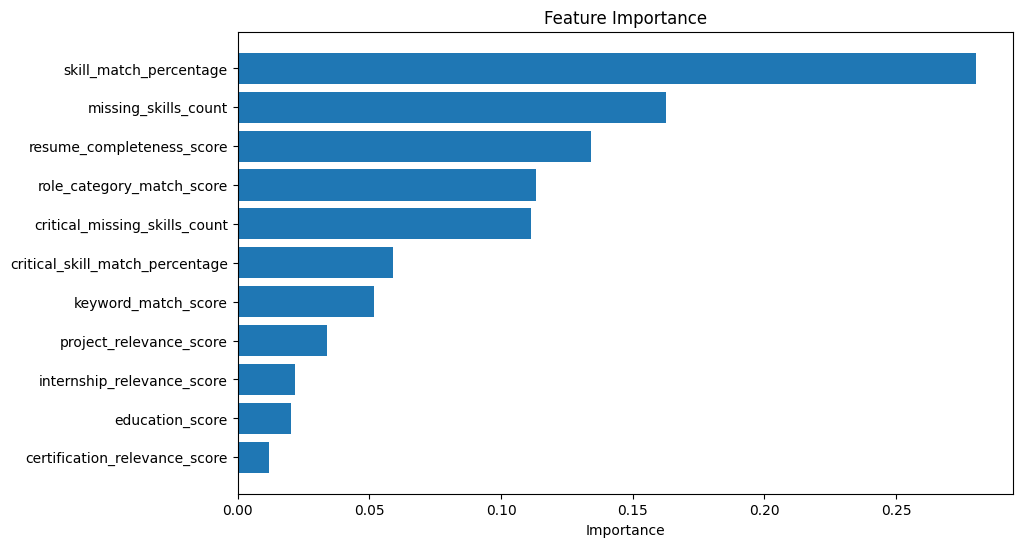

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()